In [2]:
!pip install tensorflow==2.11.0

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     |████████████████████████████████| 588.3 MB 22 kB/s 
     |████████████████████████████████| 6.0 MB 54.9 MB/s 
     |████████████████████████████████| 439 kB 78.2 MB/s 
     |████████████████████████████████| 1.7 MB 80.3 MB/s 
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.9.0
    Uninstalling tensorflow-estimator-2.9.0:
      Successfully uninstalled tensorflow-estimator-2.9.0
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.9.1
    Uninstalling tensorboard-2.9.1:
      Successfully uninstalled tensorboard-2.9.1
  Attempting uninstall: keras
    Found existing installation: keras 2.9.0
    Uninstalling keras-2.9.0:
      Successfully uninstalled keras-2.9.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 1.12
    Uninstalling flatbuffers-1.12:
      Successfully u

In [8]:
import tensorflow as tf
print(tf.__version__)

2.11.0


In [9]:
# fashion_mnist
import tensorflow as tf
from tensorflow import keras
import numpy as np

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32')
x_test  = x_test.astype('float32')

x_train = tf.reshape(x_train, (-1, 3072))
x_test  = tf.reshape(x_test, (-1, 3072))

# data normalization
x_train = x_train/255.0
x_test  = x_test/255.0

print(x_train.shape)
print(x_test.shape)

print(y_train.shape)
print(y_test.shape)

170498071/170498071 [==============================] - 14s 0us/step
(50000, 3072)
(10000, 3072)
(50000, 1)
(10000, 1)


In [10]:
import tensorflow as tf
import tensorflow.keras as keras

# set seed
tf.random.set_seed(1234)

# create model
model = keras.Sequential()
model.add(keras.Input(shape=(3072,)))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(128, activation='relu'))
model.add(keras.layers.Dense(10, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 128)               393344    
                                                                 
 dense_4 (Dense)             (None, 128)               16512     
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 411,146
Trainable params: 411,146
Non-trainable params: 0
_________________________________________________________________


In [11]:
# optimizer and loss
opt = tf.keras.optimizers.experimental.AdamW()
model.compile(optimizer=opt, 
              loss='sparse_categorical_crossentropy', 
              metrics=['sparse_categorical_accuracy'])

# training
batch_size = 256
history = model.fit(x_train, y_train, batch_size,
                    validation_data=(x_test, y_test),
                    epochs=500, verbose=2)

Epoch 1/500
196/196 - 2s - loss: 1.9135 - sparse_categorical_accuracy: 0.3135 - val_loss: 1.7896 - val_sparse_categorical_accuracy: 0.3583 - 2s/epoch - 12ms/step
Epoch 2/500
196/196 - 1s - loss: 1.7443 - sparse_categorical_accuracy: 0.3794 - val_loss: 1.6853 - val_sparse_categorical_accuracy: 0.4017 - 982ms/epoch - 5ms/step
Epoch 3/500
196/196 - 1s - loss: 1.6554 - sparse_categorical_accuracy: 0.4108 - val_loss: 1.6063 - val_sparse_categorical_accuracy: 0.4246 - 968ms/epoch - 5ms/step
Epoch 4/500
196/196 - 1s - loss: 1.6031 - sparse_categorical_accuracy: 0.4308 - val_loss: 1.6124 - val_sparse_categorical_accuracy: 0.4256 - 936ms/epoch - 5ms/step
Epoch 5/500
196/196 - 1s - loss: 1.5593 - sparse_categorical_accuracy: 0.4464 - val_loss: 1.6294 - val_sparse_categorical_accuracy: 0.4228 - 954ms/epoch - 5ms/step
Epoch 6/500
196/196 - 1s - loss: 1.5279 - sparse_categorical_accuracy: 0.4574 - val_loss: 1.5132 - val_sparse_categorical_accuracy: 0.4563 - 1s/epoch - 6ms/step
Epoch 7/500
196/196 -

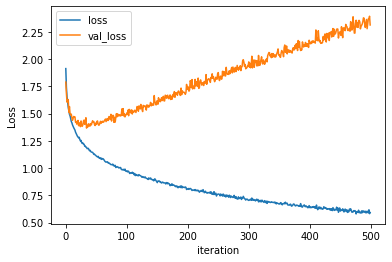

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('iteration')
plt.ylabel('Loss')
plt.legend()

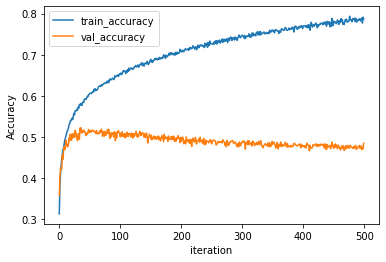

In [13]:
import matplotlib.pyplot as plt

plt.plot(history.history['sparse_categorical_accuracy'], label='train_accuracy')
plt.plot(history.history['val_sparse_categorical_accuracy'], label='val_accuracy')
plt.xlabel('iteration')
plt.ylabel('Accuracy')
plt.legend()